<a href="https://colab.research.google.com/github/anishnath02/student-performance-predictor/blob/main/Student_Score_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Student Performance Analysis**

## **Load Data**

In [142]:
import pandas as pd
import numpy as np

data = pd.read_csv('student_performance_realistic_data.csv')

In [143]:
data

,student_id,student_name,fathers_name,attendance_rate,weekly_study_hours,previous_semester_score,sleep_hours_per_night,extracurricular_activities,parental_education_level,internet_access_at_home,distance_from_school,part_time_job,learning_disability,final_score,passed
0,1,Sofia Harris,Henry Harris,89.929664,32,89.809059,4.0,0,1,1,0,0,0,72.31,1
1,2,Mia Hill,Amelia Hill,NaN,4,96.895092,5.0,1,0,0,0,0,0,64.51,1
2,3,Ava Gupta,Mason Gupta,92.843697,33,58.276141,9.0,0,0,1,1,1,0,71.98,1
3,4,Sofia Thomas,Isha Thomas,55.882199,39,55.870948,NaN,0,1,1,0,1,0,49.09,0
4,5,Mason Rodriguez,Benjamin Rodriguez,86.986517,10,56.793559,8.0,1,2,1,2,0,0,76.27,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,997,Evelyn Hill,Avery Hill,60.201233,33,60.353218,9.0,1,1,0,0,0,0,64.20,1
997,998,Michael Lee,Jacob Lee,82.699705,9,72.675727,5.0,1,1,1,2,0,0,53.56,0
998,999,Emily Wright,Aria Wright,90.918478,34,42.464090,9.0,1,2,1,2,1,0,64.07,1
999,1000,Elizabeth Hill,Avery Hill,52.500929,10,84.689505,NaN,1,1,1,1,0,0,63.46,1


In [144]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1001 non-null   int64  
 1   student_name                1001 non-null   object 
 2   fathers_name                1001 non-null   object 
 3   attendance_rate             951 non-null    float64
 4   weekly_study_hours          1001 non-null   int64  
 5   previous_semester_score     971 non-null    float64
 6   sleep_hours_per_night       961 non-null    float64
 7   extracurricular_activities  1001 non-null   int64  
 8   parental_education_level    1001 non-null   int64  
 9   internet_access_at_home     1001 non-null   int64  
 10  distance_from_school        1001 non-null   int64  
 11  part_time_job               1001 non-null   int64  
 12  learning_disability         1001 non-null   int64  
 13  final_score                 1001 

In [145]:
data.shape

(1001, 15)

## **Data Cleaning**

In [146]:
# Dropping Unwanted Columns
data.drop('fathers_name', axis=1, inplace=True)

In [147]:
data.columns

Index(['student_id', 'student_name', 'attendance_rate', 'weekly_study_hours',
       'previous_semester_score', 'sleep_hours_per_night',
       'extracurricular_activities', 'parental_education_level',
       'internet_access_at_home', 'distance_from_school', 'part_time_job',
       'learning_disability', 'final_score', 'passed'],
      dtype='object')

In [148]:
# Checking for null values
pd.isnull(data).sum()

,0
student_id,0
student_name,0
attendance_rate,50
weekly_study_hours,0
previous_semester_score,30
sleep_hours_per_night,40
extracurricular_activities,0
parental_education_level,0
internet_access_at_home,0
distance_from_school,0


In [149]:
# Dropping null values
data.dropna(inplace=True)

In [150]:
pd.isnull(data).sum()

,0
student_id,0
student_name,0
attendance_rate,0
weekly_study_hours,0
previous_semester_score,0
sleep_hours_per_night,0
extracurricular_activities,0
parental_education_level,0
internet_access_at_home,0
distance_from_school,0


In [151]:
data.shape

(885, 14)

## **Data Preparation**

### **Data Seperation as x and y**

In [152]:
from sklearn.model_selection import train_test_split
y = data['final_score']

In [153]:
y

,final_score
0,72.31
2,71.98
4,76.27
5,34.57
6,86.12
...,...
995,79.60
996,64.20
997,53.56
998,64.07


In [154]:
data.columns

Index(['student_id', 'student_name', 'attendance_rate', 'weekly_study_hours',
       'previous_semester_score', 'sleep_hours_per_night',
       'extracurricular_activities', 'parental_education_level',
       'internet_access_at_home', 'distance_from_school', 'part_time_job',
       'learning_disability', 'final_score', 'passed'],
      dtype='object')

In [155]:
x = data.drop(['final_score', 'student_id', 'student_name', 'passed', 'distance_from_school'], axis=1)
x

,attendance_rate,weekly_study_hours,previous_semester_score,sleep_hours_per_night,extracurricular_activities,parental_education_level,internet_access_at_home,part_time_job,learning_disability
0,89.929664,32,89.809059,4.0,0,1,1,0,0
2,92.843697,33,58.276141,9.0,0,0,1,1,0
4,86.986517,10,56.793559,8.0,1,2,1,0,0
5,65.983342,2,56.663145,10.0,0,0,1,1,0
6,99.420799,32,42.155811,7.0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...
995,85.043382,34,76.083044,9.0,1,0,1,0,1
996,60.201233,33,60.353218,9.0,1,1,0,0,0
997,82.699705,9,72.675727,5.0,1,1,1,0,0
998,90.918478,34,42.464090,9.0,1,2,1,1,0


In [156]:
x.columns

Index(['attendance_rate', 'weekly_study_hours', 'previous_semester_score',
       'sleep_hours_per_night', 'extracurricular_activities',
       'parental_education_level', 'internet_access_at_home', 'part_time_job',
       'learning_disability'],
      dtype='object')

### **Data Splitting**

In [157]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)

In [158]:
x_train

,attendance_rate,weekly_study_hours,previous_semester_score,sleep_hours_per_night,extracurricular_activities,parental_education_level,internet_access_at_home,part_time_job,learning_disability
455,51.101346,23,83.727173,9.0,1,1,1,0,0
239,87.049063,6,55.404610,6.0,1,1,1,1,0
797,65.504227,2,77.479838,9.0,1,1,1,0,0
171,73.648567,31,87.086181,7.0,0,2,1,0,0
373,74.570909,9,48.948450,8.0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...
967,81.260238,0,93.414197,7.0,0,0,1,0,0
985,54.215066,29,95.033236,10.0,0,1,1,0,0
943,53.416705,31,45.224272,10.0,0,1,1,0,0
896,59.571384,31,82.357374,9.0,0,1,1,0,0


In [159]:
x_test

,attendance_rate,weekly_study_hours,previous_semester_score,sleep_hours_per_night,extracurricular_activities,parental_education_level,internet_access_at_home,part_time_job,learning_disability
629,65.757352,25,45.023496,5.0,0,2,1,0,0
242,99.563161,27,99.681050,4.0,1,2,1,0,0
352,85.544236,21,68.194922,6.0,1,0,1,0,0
539,77.603468,14,81.960368,8.0,0,0,1,0,0
318,57.579215,5,64.897626,7.0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...
246,72.442654,15,86.049930,8.0,0,1,1,0,1
871,65.441721,5,92.704952,9.0,0,2,1,0,0
298,76.595635,31,74.783870,4.0,1,1,1,1,1
533,55.548876,24,53.476146,10.0,1,1,1,1,1


## **Model Building**

### **Linear Regression**

**Training the model**

In [160]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

**Applying the model to make a prediction**

In [161]:
y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)

In [164]:
y_lr_train_pred

array([57.83439316, 53.04394119, 54.56036983, 72.7544494 , 49.08346606,
       54.84247852, 63.54212416, 40.82563746, 79.68634352, 92.45180385,
       69.96389177, 65.74049822, 57.79753057, 66.21013625, 76.82408524,
       75.07396285, 55.08203592, 83.17234974, 48.01578674, 63.07743205,
       34.93827286, 51.77385577, 50.72375028, 73.88801526, 52.54342246,
       63.07456011, 57.2626008 , 55.20574475, 78.34625976, 85.20832228,
       63.47308079, 54.60191609, 71.59621203, 59.57971868, 81.96772277,
       56.39729904, 69.87182649, 64.61682123, 68.42728786, 65.66414171,
       44.74814426, 85.82935933, 33.17302734, 46.05414969, 61.69528394,
       64.09848895, 58.90393691, 66.19017674, 48.22929987, 76.52777937,
       39.8394912 , 81.18303624, 69.57643849, 59.04221236, 68.21974393,
       42.0992407 , 76.78752653, 50.68141097, 63.13368668, 43.14590617,
       61.98411228, 38.31911931, 78.8841357 , 36.20776393, 68.63201004,
       70.1296597 , 75.12430793, 54.58299201, 76.01668487, 44.63

In [165]:
y_lr_test_pred

array([48.02018895, 84.50587712, 68.47400443, 68.2963327 , 43.22814803,
       79.57296383, 75.75457651, 60.53653168, 58.99497147, 47.35102799,
       57.51233097, 78.49065685, 53.83917865, 54.81692996, 57.2714318 ,
       61.64793959, 41.96183964, 65.43415432, 39.47377153, 66.12244963,
       59.59880397, 31.52291414, 58.45021633, 34.44465725, 91.09008834,
       84.12994066, 63.37970515, 73.95143666, 74.11771217, 67.12002782,
       54.63348013, 47.88594433, 77.86629633, 46.09932921, 56.35880048,
       50.22398828, 60.09521522, 59.69593531, 47.45679028, 54.28238752,
       45.89477125, 52.85540734, 62.35655477, 67.62431743, 69.36485605,
       54.99038598, 69.2913527 , 69.24020352, 49.61912287, 58.82839134,
       70.59043968, 72.92690495, 61.70749867, 62.54414911, 33.40554726,
       44.80554964, 82.17544935, 91.66763324, 64.14213188, 57.89888368,
       75.90719732, 64.30997649, 69.14134535, 65.19785094, 62.57931152,
       66.85157451, 48.03882703, 66.05732273, 59.5947976 , 64.06

**Evaluate model performance**

*Let's check the dispersion.* **Lower Dispersion means better result**

In [166]:
from sklearn.metrics import mean_squared_error, r2_score

lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

In [173]:
print('LR MSE (Train):',lr_train_mse)
print('LR R2 (Train):',lr_train_r2)
print('LR MSE (Test):',lr_test_mse)
print('LR R2 (Test):',lr_test_r2)

LR MSE (Train): 53.9040672293529
LR R2 (Train): 0.7539398397233563
LR MSE (Test): 57.19522929675728
LR R2 (Test): 0.77021710276389


In [174]:
lr_results = pd.DataFrame(['Linear Regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']

In [175]:
lr_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,53.904067,0.75394,57.195229,0.770217


### **Random Forest**

**Training the model**

In [176]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(max_depth=5, random_state=100)
rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=5, random_state=100)

**Applying the model to make a prediction**

In [177]:
y_rf_train_pred = rf.predict(x_train)
y_rf_test_pred = rf.predict(x_test)

**Evaluate model performance**

In [178]:
from sklearn.metrics import mean_squared_error, r2_score

rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)
rf_train_r2 = r2_score(y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)

In [179]:
print('RF MSE (Train):',rf_train_mse)
print('RF R2 (Train):',rf_train_r2)
print('RF MSE (Test):',rf_test_mse)
print('RF R2 (Test):',rf_test_r2)

RF MSE (Train): 29.331674042387313
RF R2 (Train): 0.866107386937178
RF MSE (Test): 50.4475102572895
RF R2 (Test): 0.7973261894777371


In [180]:
rf_results = pd.DataFrame(['Random Forest', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']

In [181]:
rf_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Random Forest,29.331674,0.866107,50.44751,0.797326


## **Model Comparison**

In [182]:
df_models = pd.concat([lr_results, rf_results], axis=0)
df_models.reset_index(drop=True, inplace=True)

In [183]:
df_models

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,53.904067,0.75394,57.195229,0.770217
1,Random Forest,29.331674,0.866107,50.44751,0.797326


## **Data Visualization of prediction results**

### **Training Data**

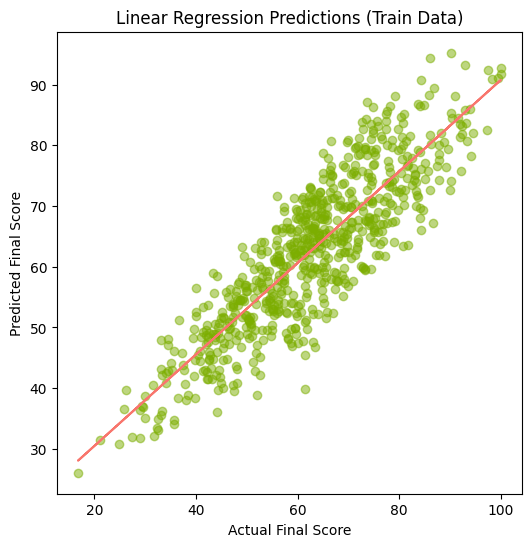

In [223]:
# Linear Regression
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(x=y_train, y=y_lr_train_pred, c='#7CAE00', alpha=0.5)

z = np.polyfit(y_train, y_lr_train_pred, 1)
p = np.poly1d(z)

plt.plot(y_train, p(y_train), '#F8766D')
plt.ylabel('Predicted Final Score')
plt.xlabel('Actual Final Score')
plt.title('Linear Regression Predictions (Train Data)')
plt.show()

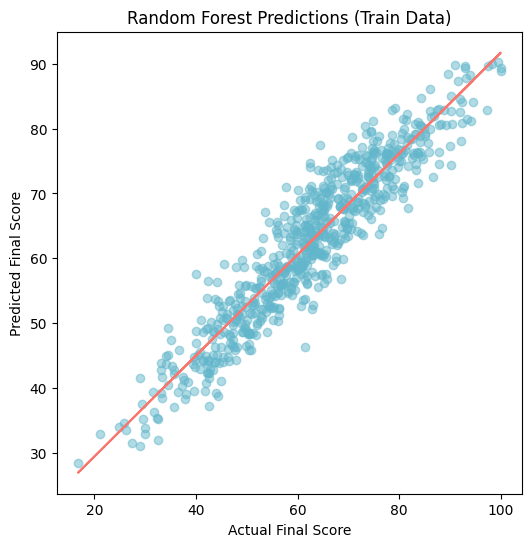

In [224]:
# Random Forest
plt.figure(figsize=(6,6))
plt.scatter(x=y_train, y=y_rf_train_pred, c='#62b6cb', alpha=0.5)

z = np.polyfit(y_train, y_rf_train_pred, 1)
p = np.poly1d(z)

plt.plot(y_train, p(y_train), '#F8766D')
plt.ylabel('Predicted Final Score')
plt.xlabel('Actual Final Score')
plt.title('Random Forest Predictions (Train Data)')
plt.show()

### **Testing Data**

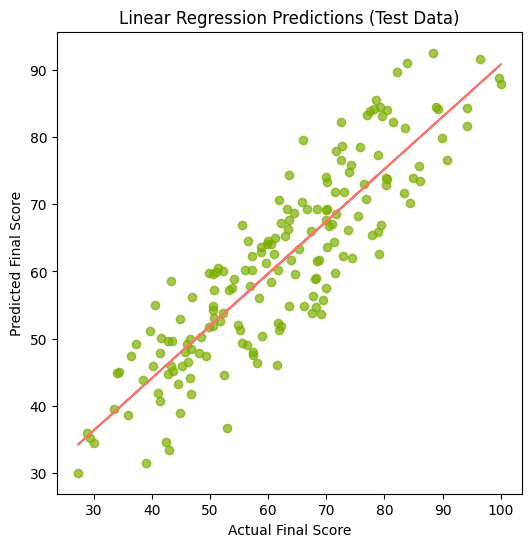

In [225]:
# Linear Regression
plt.figure(figsize=(6,6))
plt.scatter(x=y_test, y=y_lr_test_pred, c='#7CAE00', alpha=0.7)

z = np.polyfit(y_test, y_lr_test_pred, 1)
p = np.poly1d(z)

plt.plot(y_test, p(y_test), '#F8766D')
plt.ylabel('Predicted Final Score')
plt.xlabel('Actual Final Score')
plt.title('Linear Regression Predictions (Test Data)')
plt.show()

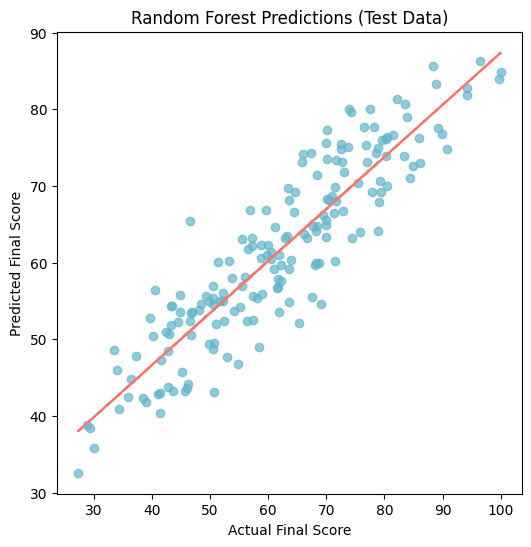

In [226]:
# Random Forest
plt.figure(figsize=(6,6))
plt.scatter(x=y_test, y=y_rf_test_pred, c='#62b6cb', alpha=0.7)

z = np.polyfit(y_test, y_rf_test_pred, 1)
p = np.poly1d(z)

plt.plot(y_test, p(y_test), '#F8766D')
plt.ylabel('Predicted Final Score')
plt.xlabel('Actual Final Score')
plt.title('Random Forest Predictions (Test Data)')
plt.show()